Attribution: this assignment was done in vscode with claude code in the command line. Claude was used mostly to generate plots given specific instructions or to do pandas work. I did the vast majority of conceptual work and AI was used primarily for boilerplate. 

# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Setup: Clone the Data Repository

Before starting, you need to clone the course data repository to access the datasets:

```bash
git clone https://github.com/noise-courses/data.git
```

This repository contains the Netflix packet capture needed for this assignment in the `data/video-qoe/` directory.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file from `data/video-qoe/netflix.pcap`, which is a packet trace that includes network traffic.

In [147]:
from netml.pparser.parser import PCAP

pcap = PCAP('../data/video-qoe/netflix.pcap')

pcap.pcap2pandas()

pdf = pcap.df

In [90]:
pdf.head(5)

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
0,2018-02-11 15:10:00,"(fonts.gstatic.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,77,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,55697.0,UDP,1518358200.534682,0.000000
1,2018-02-11 15:10:00,"(fonts.gstatic.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,77,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,59884.0,UDP,1518358200.534832,0.000150
2,2018-02-11 15:10:00,"(googleads.g.doubleclick.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,87,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,61223.0,UDP,1518358200.539408,0.004726
3,2018-02-11 15:10:00,"(googleads.g.doubleclick.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,87,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,58785.0,UDP,1518358200.541204,0.006522
4,2018-02-11 15:10:00,"(ytimg.l.google.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,51938.0,UDP,1518358200.545785,0.011103


### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [148]:
from scapy.all import PcapReader, DNS

# Get IP adresses of all Netflix video servers
ip2host = {}
with PcapReader('../data/video-qoe/netflix.pcap') as r:
    for pkt in r:
        if DNS in pkt and pkt[DNS].ancount:
            for i in range(pkt[DNS].ancount):
                rr = pkt[DNS].an[i]
                if rr.type == 1:                      # A record only
                    ip2host[rr.rdata] = rr.rrname.decode().rstrip('.')

video_ips = {ip for ip, h in ip2host.items() if 'nflxvideo' in h}   # We only want Netflix video, not any other Netflix packets
print(video_ips, len(ip2host))

{'198.38.120.167', '198.38.120.153', '198.38.120.134', '198.38.120.130', '198.38.120.164', '198.38.120.166', '198.38.120.162'} 32


In [92]:
# Get packets in trace originating from / destined for Netflix video servers
nflx = pdf[pdf.ip_src.isin(video_ips) | pdf.ip_dst.isin(video_ips)]

In [93]:
nflx.head(5) # ~135k rows total

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
107,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58451.0,TCP,1518358202.903273,2.368591
109,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58452.0,TCP,1518358202.903319,2.368637
110,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58453.0,TCP,1518358202.903415,2.368733
124,2018-02-11 15:10:02,None,None,198.38.120.153,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58464.0,TCP,1518358202.904561,2.369879
125,2018-02-11 15:10:02,None,None,198.38.120.153,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58465.0,TCP,1518358202.904633,2.369951


In [94]:
# Add information on whether packets are sent or recieved by the client 

# Inferred from nflx.head()
CLIENT = '192.168.43.72'

nflx = nflx.copy()
nflx['direction'] = (nflx.ip_dst == CLIENT).map({True: 'down', False: 'up'})
nflx.head(5)

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed,direction
107,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58451.0,TCP,1518358202.903273,2.368591,up
109,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58452.0,TCP,1518358202.903319,2.368637,up
110,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58453.0,TCP,1518358202.903415,2.368733,up
124,2018-02-11 15:10:02,None,None,198.38.120.153,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58464.0,TCP,1518358202.904561,2.369879,up
125,2018-02-11 15:10:02,None,None,198.38.120.153,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58465.0,TCP,1518358202.904633,2.369951,up


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [95]:
# Put packets in 1s bins (the model will read these sequentially)
BIN_SIZE = 1.0   # seconds

start_time = nflx.time.min()
elapsed = nflx.time - start_time
nflx['bin'] = (elapsed // BIN_SIZE).astype(int)


# Get the following attributes per bin for each direction (up / down):
# (*) Combined size of all packets (bytes) in bin
# (*) Total number of packets in bin
# (*) Mean size of packets in (bytes) in bin; this can already be calculated from the above characteristics, but it should
# help the model, since an active download would probably have a large mean packet size
agg = (nflx.groupby(['bin', 'direction'])
            .agg(bytes=('length', 'sum'), pkts=('length', 'size'), mean_size=('length', 'mean'))
            .unstack('direction', fill_value=0))

agg.columns = [f'{d}_{m}' for m, d in agg.columns]

bins = (agg.reindex(range(nflx.bin.max() + 1), fill_value=0)
           .rename_axis('bin')
           .reset_index())

# For interpretability; this won't actually be fed into the model 
bins['down_mbps'] = bins.down_bytes * 8 / 1e6
bins['up_mbps'] = bins.up_bytes * 8 / 1e6

bins.head()

,bin,down_bytes,up_bytes,down_pkts,up_pkts,down_mean_size,up_mean_size,down_mbps,up_mbps
0,0,666,3564,9,33,74.000000,108.000000,0.005328,0.028512
1,1,1804,1026,13,11,138.769231,93.272727,0.014432,0.008208
2,2,4264,2658,24,26,177.666667,102.230769,0.034112,0.021264
3,3,370,1208,5,10,74.000000,120.800000,0.002960,0.009664
4,4,4724,1980,31,30,152.387097,66.000000,0.037792,0.015840


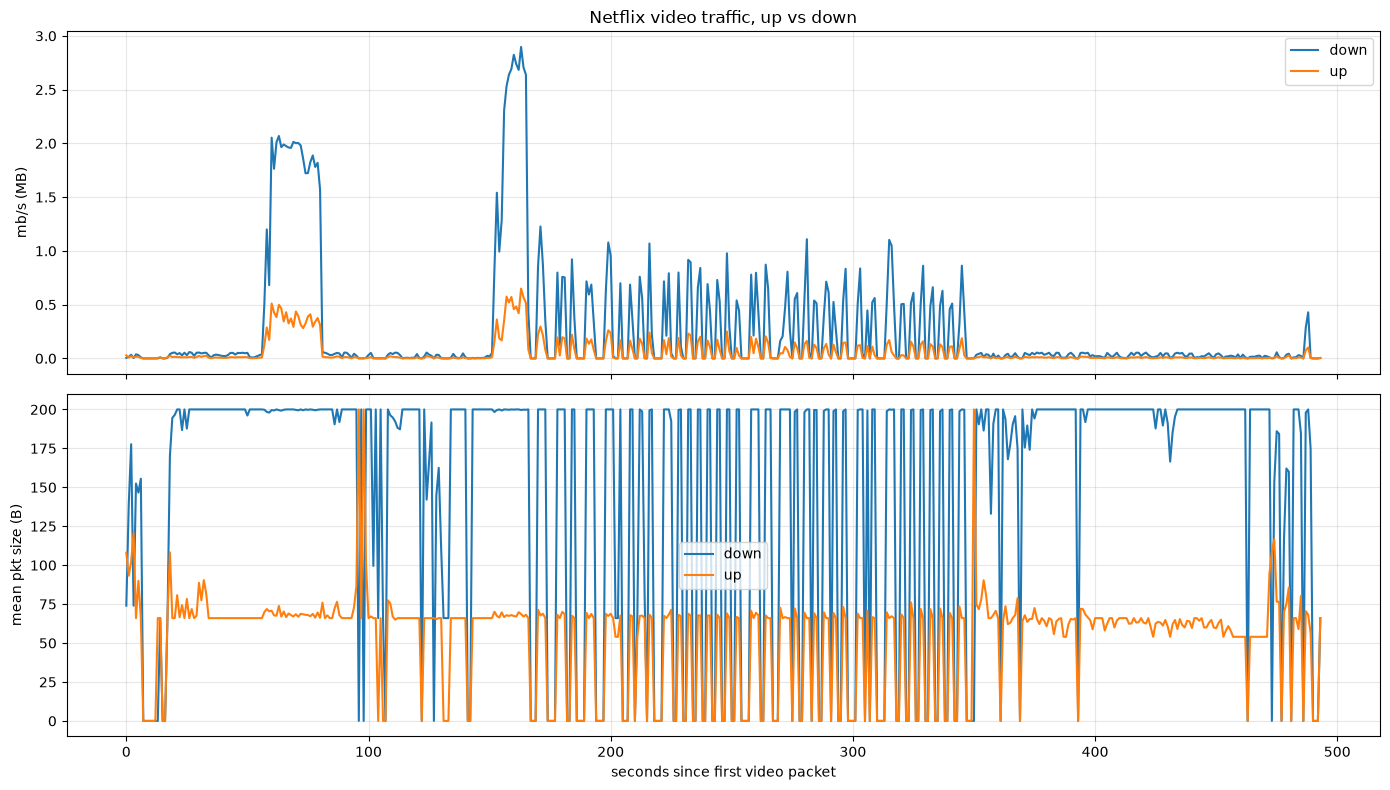

In [96]:
# Visualize the time series (one plot for up packets, one for down packets)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for d in ['down', 'up']:
    ax[0].plot(bins['bin'], bins[f'{d}_bytes'] * 8 / 1e6, label=d)
    ax[1].plot(bins['bin'], bins[f'{d}_mean_size'], label=d)

ax[0].set_ylabel('mb/s (MB)')
ax[0].set_title('Netflix video traffic, up vs down')
ax[1].set_ylabel('mean pkt size (B)')
ax[1].set_xlabel('seconds since first video packet')

for a in ax:
    a.grid(alpha=0.3)
    a.legend()

plt.tight_layout()
plt.show()

**Write a brief justification for the features that you have chosen.**

I first decided to bin all of the packet information into 1s intervals to make the sequence uniform. Packet traces are irregularly sampled, and since I'm planning on using an LSTM, I want the model to be able to always expect time t+1 to always be 1s after time t rather than having to infer elapsed time from the data. Binning also shortens the sequence to something more trainable. 

I further divided the data into down / up packets. A steady amount of up packets (the client is still requesting data) coupled with a decrease in down packets would signal a quality drop, while having barely up packets and barely down packets would suggest the network is stalling. The prior of these two observations might be much harder for the model to learn if the down / up division was not implemented. I wouldn't be surprised if the model could infer video quality based on just the down packets, though, but the up packets could still be useful. 

Giving the model access to the number of bytes sent up and down per second will allow it to infer how much data is being loaded to the client. Since higher quality video means more bytes sent, bytes per second could act as an important signal to the model. Packets per second generally seems to be highly correlated with bytes per second in this dataset, but I figure it can't hurt to give the model both. I also gave the model the mean packet size in bytes. Although this information could be inferred from the other columns, explicity providing the mean packet size will make the model's job a bit easier. This statistic is also probably correlated with video quality, since I'd assume that 4K video would have the server sending bigger packets that 240p. 

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

A segment download is a sudden burst of activity, and between segments down traffic should be quiet. I'm going to try and find threshold I can use to define 'not quiet' so we can try to infer what is a video segment and what isn't.

In [97]:
for t in [bins.down_bytes.median(), 0.1*bins.down_bytes.max(), 1e5]:
    a = bins.down_bytes > t
    n = (a & ~a.shift(1, fill_value=False)).sum()
    print(f'thresh {t:.0f}: {n} segments, {len(bins)/max(n,1):.1f}s apart')

thresh 3800: 82 segments, 6.0s apart
thresh 36215: 43 segments, 11.5s apart
thresh 100000: 18 segments, 27.4s apart


The median seems like the best choice. The last two are too aggressive I think (11.5s and 27.4s gaps between segments don't sound right).

In [98]:
THRESH = 3800
active = bins.down_bytes > THRESH

bins['downloading'] = active.astype(int)    # Boolean value for if a bin is said to representing "downloading" data
bins['segments'] = (active & ~active.shift(1, fill_value=False)).astype(int)    # Finds where the download segment starts and ends

# We use a ten second window (starting from this bin and the nine before it, where NaN values are ignored) then average.
# The window is centered since we don't want to leak future information and mess with the timeseries. 
bins['seg_rate_10s'] = bins.segments.rolling(10, min_periods=1).mean() 

bins.head(20)

,bin,down_bytes,up_bytes,down_pkts,up_pkts,down_mean_size,up_mean_size,down_mbps,up_mbps,downloading,segments,seg_rate_10s
0,0,666,3564,9,33,74.000000,108.000000,0.005328,0.028512,0,0,0.000000
1,1,1804,1026,13,11,138.769231,93.272727,0.014432,0.008208,0,0,0.000000
2,2,4264,2658,24,26,177.666667,102.230769,0.034112,0.021264,1,1,0.333333
3,3,370,1208,5,10,74.000000,120.800000,0.002960,0.009664,0,0,0.250000
4,4,4724,1980,31,30,152.387097,66.000000,0.037792,0.015840,1,1,0.400000
5,5,3811,1890,26,21,146.576923,90.000000,0.030488,0.015120,1,0,0.333333
6,6,1244,528,8,8,155.500000,66.000000,0.009952,0.004224,0,0,0.285714
7,7,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.250000
8,8,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.222222
9,9,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.200000


## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

Two datasets are available in the data repository:

1. **netflix_dataset.pkl** (52,279 samples, 251 features) - Netflix-only data
2. **video_dataset.pkl** (204,713 samples, 170 features) - Multi-service data (Netflix, YouTube, Twitch, Amazon Prime)

Decompress the dataset you want to use:

```bash
# Option 1: Netflix-only dataset (105 MB uncompressed)
xz -d data/video-qoe/netflix_dataset.pkl.xz

# Option 2: Multi-service dataset (265 MB uncompressed)
xz -d data/video-qoe/video_dataset.pkl.xz
```

You can use either dataset for this assignment. The multi-service dataset has more samples but fewer features.

### Load the File

Load the video dataset pickle file.

In [99]:
import pandas as pd

df = pd.read_pickle('../data/video-qoe/video_dataset.pkl')
df.head()

,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_50,...,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.1,43473.0,185098.0,361832.3,461040.2,539882,4380,185126.042201,1.548881e+09,161.5,...,19684.624818,57.462837,985.136457,0,4,0.0,0,0.108730,0.557937,netflix
1,91984.2,101882.0,122323.0,159843.4,181011.8,196778,24498,62449.107359,1.548881e+09,361.0,...,8183.942278,71.011784,310.123152,0,1,0.0,0,0.116865,0.549802,netflix
2,147725.0,111373.0,224157.0,286280.0,325845.8,396800,24498,134268.559725,1.548881e+09,337.0,...,7087.849223,85.198800,149.669427,0,0,0.0,0,0.126852,0.539815,netflix
3,246420.6,297522.0,330737.5,361030.7,378404.0,396800,24498,127394.372454,1.548881e+09,399.0,...,56963.445789,109.397055,14006.713648,0,1,0.0,0,0.186111,0.480556,netflix
4,336681.0,354461.0,399719.5,409866.3,414060.0,438000,198238,79844.367998,1.548881e+09,414.0,...,10988.579443,122.132897,13261.305817,0,0,0.0,0,0.194444,0.472222,netflix


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [100]:
# Drop unneeded entries
df = df[df.resolution.isin([240, 360, 480, 720, 1080])].copy().reset_index(drop=True)
df.head()

,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_50,...,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.1,43473.0,185098.0,361832.3,461040.2,539882,4380,185126.042201,1.548881e+09,161.5,...,19684.624818,57.462837,985.136457,0,4,0.0,0,0.108730,0.557937,netflix
1,91984.2,101882.0,122323.0,159843.4,181011.8,196778,24498,62449.107359,1.548881e+09,361.0,...,8183.942278,71.011784,310.123152,0,1,0.0,0,0.116865,0.549802,netflix
2,147725.0,111373.0,224157.0,286280.0,325845.8,396800,24498,134268.559725,1.548881e+09,337.0,...,7087.849223,85.198800,149.669427,0,0,0.0,0,0.126852,0.539815,netflix
3,246420.6,297522.0,330737.5,361030.7,378404.0,396800,24498,127394.372454,1.548881e+09,399.0,...,56963.445789,109.397055,14006.713648,0,1,0.0,0,0.186111,0.480556,netflix
4,336681.0,354461.0,399719.5,409866.3,414060.0,438000,198238,79844.367998,1.548881e+09,414.0,...,10988.579443,122.132897,13261.305817,0,0,0.0,0,0.194444,0.472222,netflix


2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [101]:
# Begin by listing out all of the rows present 
for i in df.columns.tolist():
    print(i)

L7_10_avg_chunksize
L7_10_chunksizes_50
L7_10_chunksizes_75
L7_10_chunksizes_85
L7_10_chunksizes_90
L7_10_max_chunksize
L7_10_min_chunksize
L7_10_std_chunksize
absolute_timestamp
L7_all_prev_down_chunk_iat_50
L7_all_prev_down_chunk_iat_75
L7_all_prev_down_chunk_iat_85
L7_all_prev_down_chunk_iat_90
L7_all_prev_down_chunk_iat_avg
L7_all_prev_down_chunk_iat_max
L7_all_prev_down_chunk_iat_min
L7_all_prev_down_chunk_iat_std
L7_all_prev_up_chunk_iat_50
L7_all_prev_up_chunk_iat_75
L7_all_prev_up_chunk_iat_85
L7_all_prev_up_chunk_iat_90
L7_all_prev_up_chunk_iat_avg
L7_all_prev_up_chunk_iat_max
L7_all_prev_up_chunk_iat_min
L7_all_prev_up_chunk_iat_std
L7_allprev_avg_chunksize
L7_allprev_chunksizes_50
L7_allprev_chunksizes_75
L7_allprev_chunksizes_85
L7_allprev_chunksizes_90
L7_allprev_max_chunksize
L7_allprev_min_chunksize
L7_allprev_std_chunksize
L7_cumsum_chunksizes
L7_cumsum_diff
L7_down_chunk_iat_50
L7_down_chunk_iat_75
L7_down_chunk_iat_85
L7_down_chunk_iat_90
L7_down_chunk_iat_avg
L7_down

In [102]:
# Drop the home id and video id; we'll use the session id for the train / test split. 
IDs = ["home_id", "video_id"]

df = df.drop(columns=IDs)

# Drop any constant columns; they give us no information. 
nunique = df.nunique()
constant = nunique[nunique <= 1].index.tolist()

df = df.drop(columns=constant)

# Absolute timestamp will not help and might cause the model to see patterns that aren't there
ts = df.absolute_timestamp.values   # We need this later when making the LSTM sequences
df = df.drop(columns="absolute_timestamp")

# We shouldn't learn resolution based on how far into the video we are
pos = ["video_position", "relative_timestamp"]
df = df.drop(columns=pos)

# We're only working with netflix
df = df.drop(columns="service")

In [103]:
df.head()

,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,L7_all_prev_down_chunk_iat_50,L7_all_prev_down_chunk_iat_75,...,L4_userStdBytesInFlight,L4_userStdBytesPerPacket,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userXRetransmit,L4_userZeroRetransmit
0,148947.1,43473.0,185098.0,361832.3,461040.2,539882,4380,185126.042201,161.5,602.50,...,330.414175,94.051096,19684.624818,57.462837,985.136457,0,4,0.0,0.108730,0.557937
1,91984.2,101882.0,122323.0,159843.4,181011.8,196778,24498,62449.107359,361.0,614.00,...,361.139739,119.846893,8183.942278,71.011784,310.123152,0,1,0.0,0.116865,0.549802
2,147725.0,111373.0,224157.0,286280.0,325845.8,396800,24498,134268.559725,337.0,620.00,...,361.942841,111.889532,7087.849223,85.198800,149.669427,0,0,0.0,0.126852,0.539815
3,246420.6,297522.0,330737.5,361030.7,378404.0,396800,24498,127394.372454,399.0,652.00,...,363.797811,79.787976,56963.445789,109.397055,14006.713648,0,1,0.0,0.186111,0.480556
4,336681.0,354461.0,399719.5,409866.3,414060.0,438000,198238,79844.367998,414.0,782.25,...,377.300424,65.877408,10988.579443,122.132897,13261.305817,0,0,0.0,0.194444,0.472222


**Briefly explain why you removed those columns.**

I removed all of the constant columns since they do not give the model information. I removed most of the IDs as well since they should have no bearing on the resolution, likewise with the absolute timestamp. If I kept these columns the model might learn relationships that are non-existent or overfit. I kept the session ID so I can use it in the train / test split. I also removed information regarding how long into the video we are, since this could spuriously correlate with resolution. 

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [104]:
# Seperate the target and groups
import numpy as np, pandas as pd, torch

y_raw = df.resolution.values
groups = df.session_id.values
X_df = df.drop(columns=['resolution', 'session_id']) # What the model gets

# Make all of the class indices 0-4 for CrossEntropyLoss
LADDER = [240, 360, 480, 720, 1080]
res2idx = {r: i for i, r in enumerate(LADDER)}
y = np.array([res2idx[r] for r in y_raw])

# Split by session: 60 / 20 / 20 train / val / test.
# The validation set is held out from training entirely and is what we use to
# measure loss for the LR scheduler (and later for hyperparameter tuning), so
# the test set stays untouched until the final evaluation.
from sklearn.model_selection import GroupShuffleSplit

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trval, te = next(gss_test.split(X_df, y, groups=groups))

# Carve the validation set out of the remaining sessions (0.25 * 0.8 = 0.2 of all data)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_rel, va_rel = next(gss_val.split(X_df.iloc[trval], y[trval], groups=groups[trval]))
tr, va = trval[tr_rel], trval[va_rel]   # X_df.iloc[tr] gives us the training rows, y[tr] the matching labels

# Sanity check: no session may appear in more than one split
assert not (set(groups[tr]) & set(groups[va]))
assert not (set(groups[tr]) & set(groups[te]))
assert not (set(groups[va]) & set(groups[te]))
print(f'{len(tr)} train / {len(va)} val / {len(te)} test rows')
print(f'{len(set(groups[tr]))} / {len(set(groups[va]))} / {len(set(groups[te]))} sessions')

X_df = X_df.apply(pd.to_numeric, errors='coerce') # Turn any stray strings or weird stuff to NaNs
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0) # Make NaNs and infinities zero

# Scale the data but fit only on the train set to prevent leakage into val / test
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_df.iloc[tr])
X = scaler.transform(X_df).astype(np.float32)

119710 train / 40085 val / 40268 test rows
2397 / 799 / 800 sessions


In [105]:
# Get sequences for the LSTM
from torch.nn.utils.rnn import pad_sequence

def build_sequences(idx, X, y, groups, ts):
    """idx: row positions for this split. Returns padded tensors + lengths."""
    Xs, ys, gs, tss = X[idx], y[idx], groups[idx], ts[idx]

    seqs, labs = [], []
    for sid in np.unique(gs):
        m = gs == sid
        order = np.argsort(tss[m])                      # time order within session
        seqs.append(torch.tensor(Xs[m][order], dtype=torch.float32))
        labs.append(torch.tensor(ys[m][order], dtype=torch.long))

    lengths = torch.tensor([len(s) for s in seqs])
    Xpad = pad_sequence(seqs, batch_first=True)
    ypad = pad_sequence(labs, batch_first=True, padding_value=-100) # Pytorch ignores the -100s 
    return Xpad, ypad, lengths


Xtr, ytr, len_tr = build_sequences(tr, X, y, groups, ts)
Xva, yva, len_va = build_sequences(va, X, y, groups, ts)
Xte, yte, len_te = build_sequences(te, X, y, groups, ts)

print(Xtr.shape, ytr.shape, len_tr.min().item(), len_tr.max().item())
print(Xva.shape, yva.shape, len_va.min().item(), len_va.max().item())
print(Xte.shape, yte.shape, len_te.min().item(), len_te.max().item())
# (rows, max timesteps, features), (rows, max timesteps), ...

torch.Size([2397, 72, 159]) torch.Size([2397, 72]) 4 72
torch.Size([799, 72, 159]) torch.Size([799, 72]) 1 72
torch.Size([800, 71, 159]) torch.Size([800, 71]) 7 71


In [106]:
import numpy as np
print(np.percentile(len_tr.numpy(), [10, 25, 50, 75, 90]))
print((len_tr == 1).sum().item(), 'sessions with a single row')

# No single rows. We're safe for the LSTM.

[47. 47. 48. 49. 60.]
0 sessions with a single row


In [107]:
# Instantiate torch stuff
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
torch.manual_seed(0)  # reproducibility

In [108]:
# Let's make the pytorch dataset
class FlowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.long)   # Cross entropy loss expects integer indices

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# (batch, seq, features)
train_ds = FlowDataset(Xtr, ytr)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

val_ds = FlowDataset(Xva, yva)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

test_ds = FlowDataset(Xte, yte)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [149]:
from tqdm.auto import tqdm    # .auto picks the notebook widget bar when one is available

# Default pytorch lstm
class QoELSTM(nn.Module):
    def __init__(self, n_features, n_classes=5, hidden=64, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(input_size=n_features, 
                            hidden_size=hidden, 
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)   # dropout between stacked layers only

        # Applied to the LSTM's output before the head, on by default so every model we
        # instantiate from this class gets some regularization against memorizing sessions.
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, n_classes)

    def forward(self, x):                 # x: (batch, seq, n_features)
        out, _ = self.lstm(x)             # out: (batch, seq, hidden)
        out = self.dropout(out)
        return self.head(out)  # (batch, seq, n_classes)

features = Xtr.shape[2]
model = QoELSTM(n_features=features)
model.to(device)


import torch.nn as nn, torch.optim as optim

criterion = nn.CrossEntropyLoss()          # ignore_index=-100 is the default
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                factor=0.5, patience=3)

def batch_stats(logits, y, criterion):
    """Flatten (batch, seq, classes) -> (N, classes) and score only real timesteps."""
    flat_logits = logits.reshape(-1, logits.size(-1))
    flat_y = y.reshape(-1)
    loss = criterion(flat_logits, flat_y)

    mask = flat_y != -100                      # padding is ignored in the metrics too
    correct = (flat_logits.argmax(-1)[mask] == flat_y[mask]).sum().item()
    return loss, correct, int(mask.sum().item())


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                       # enables dropout, batchnorm updates
    total_loss, correct, n = 0.0, 0, 0

    # No per-batch progress bar here: nesting it under the per-epoch/per-lr bar above it
    # made tqdm spawn a fresh line under the main bar on every single epoch.
    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()           # clear gradients from last step
        logits = model(X)               # forward
        loss, c, k = batch_stats(logits, y, criterion)     # compute loss
        loss.backward()                 # backward: fills .grad

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)    # prevent gradient explosions

        optimizer.step()                # update weights

        total_loss += loss.item() * k   # weight by number of real (unpadded) timesteps
        correct += c
        n += k

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Same accounting as training, but no gradients and no weight updates."""
    model.eval()                        # disables dropout etc.
    total_loss, correct, n = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss, c, k = batch_stats(logits, y, criterion)

        total_loss += loss.item() * k
        correct += c
        n += k

    return total_loss / n, correct / n

def train_model():
    EPOCHS = 10
    history = []
    best_val_loss, best_state = float('inf'), None

    epochs = tqdm(range(EPOCHS), desc='training', unit='epoch')
    for epoch in epochs:
        train_loss, train_acc = train_one_epoch(model=model,
                                                loader=train_loader,
                                                criterion=criterion,
                                                optimizer=optimizer,
                                                device=device)

        # Step the scheduler on validation loss, not training loss: training loss almost
        # always keeps falling, so it would never look like a plateau, and the test set
        # has to stay unseen until the final evaluation.
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        prev_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]['lr']

        history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                        'val_loss': val_loss, 'val_acc': val_acc, 'lr': lr})

        # Keep the weights from the best validation epoch so a late overfit doesn't cost us
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # The epoch losses ride on the bar itself; '*' marks a new best validation loss
        epochs.set_postfix(train=f'{train_loss:.4f}', val=f'{val_loss:.4f}',
                        val_acc=f'{val_acc:.3f}', best='*' if is_best else ' ')

        # tqdm.write prints above the bar instead of scrambling it
        if lr < prev_lr:
            tqdm.write(f'epoch {epoch}: val loss plateaued, lr {prev_lr:.2e} -> {lr:.2e}')

    # Restore the best checkpoint before evaluating / tuning
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'best val loss: {best_val_loss:.4f}')

    return history, best_val_loss

history, best_val_loss = train_model()

training:   0%|          | 0/10 [00:00<?, ?epoch/s]

training: 100%|██████████| 10/10 [00:06<00:00,  1.60epoch/s, best=, train=0.3005, val=0.4120, val_acc=0.852]

best val loss: 0.4083


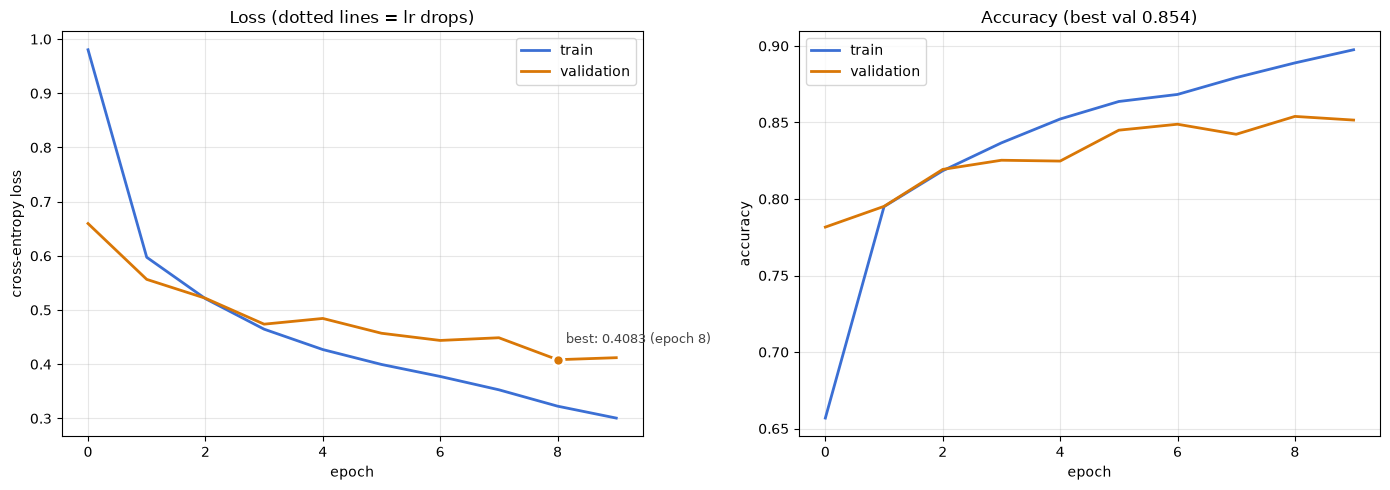

In [150]:
# Learning curves: the gap between the two lines is the overfitting story
import matplotlib.pyplot as plt

def plot_stats(history):
    hist = pd.DataFrame(history)
    best = hist.val_loss.idxmin()

    TRAIN_C, VAL_C = '#3b6fd4', '#d97706'   # kept distinguishable under colorblindness

    fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    for a, (metric, label) in zip(ax, [('loss', 'cross-entropy loss'), ('acc', 'accuracy')]):
        a.plot(hist.epoch, hist[f'train_{metric}'], color=TRAIN_C, lw=2, label='train')
        a.plot(hist.epoch, hist[f'val_{metric}'], color=VAL_C, lw=2, label='validation')

        # Every epoch where ReduceLROnPlateau halved the learning rate
        for e in hist.epoch[hist.lr.diff() < 0]:
            a.axvline(e, color='gray', lw=1, ls=':', zorder=0)

        a.set_ylabel(label)
        a.set_xlabel('epoch')
        a.grid(alpha=0.3)
        a.legend()

    # Label the checkpoint we actually kept
    ax[0].plot(best, hist.val_loss[best], 'o', ms=8, color=VAL_C,
            mec='white', mew=2, zorder=3)
    ax[0].annotate(f'best: {hist.val_loss[best]:.4f} (epoch {best})',
                xy=(best, hist.val_loss[best]), xytext=(6, 12),
                textcoords='offset points', fontsize=9, color='#444')

    ax[0].set_title('Loss (dotted lines = lr drops)')
    ax[1].set_title(f'Accuracy (best val {hist.val_acc[best]:.3f})')

    plt.tight_layout()
    plt.show()

plot_stats(history)

Overfitting looks like a risk here since the train loss is steadily decreasing but the validation loss plateaus (same behavior when pushing epochs up but worse). Could be class imbalance? Will sort out when I tune the hyperparameters and after I save the model. 

### Save the Trained Model

Checkpoint the best weights along with everything needed to use them again: the scaler, the feature order, the class ladder, and the training history.

In [152]:
from pathlib import Path
import json, joblib

CKPT_DIR = Path('checkpoints/m1')

def save_model(ckpt_dir):
    # The weights are useless without the exact preprocessing that produced them, so the
    # scaler, the feature order and the label ladder travel with the state dict.
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / 'qoe_lstm.pt'

    torch.save({
        'state_dict': model.state_dict(),          # already the best-val-loss checkpoint
        'model_class': 'QoELSTM',
        'model_kwargs': {
            'n_features': model.lstm.input_size,
            'n_classes': model.head.out_features,
            'hidden': model.lstm.hidden_size,
            'num_layers': model.lstm.num_layers,
            'dropout': model.dropout.p,
        },  # derived from the actual model, so saved metadata can never drift from the real architecture
        'feature_names': list(X_df.columns),
        'ladder': LADDER,
        'best_val_loss': best_val_loss,
        'history': history,
    }, ckpt_path)
    
    joblib.dump(scaler, ckpt_dir / 'scaler.joblib')

    with open(ckpt_dir / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

    print(f'saved {ckpt_path} ({ckpt_path.stat().st_size / 1e6:.1f} MB), best val loss {best_val_loss:.4f}')

save_model(CKPT_DIR)

saved checkpoints/m1/qoe_lstm.pt (0.4 MB), best val loss 0.4083


In [153]:
def load_model(ckpt_dir):
    # Reload the checkpoint (run this instead of retraining once the weights exist)
    ckpt_path = ckpt_dir / 'qoe_lstm.pt'
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    model = QoELSTM(**ckpt['model_kwargs']).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    scaler = joblib.load(ckpt_dir / 'scaler.joblib')
    FEATURE_NAMES = ckpt['feature_names']   # column order the scaler / model expect
    LADDER = ckpt['ladder']

    print(f"loaded model trained to val loss {ckpt['best_val_loss']:.4f} over {len(ckpt['history'])} epochs")

    return model

load_model(ckpt_dir=CKPT_DIR)

loaded model trained to val loss 0.4083 over 10 epochs


QoELSTM(
  (lstm): LSTM(159, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=64, out_features=5, bias=True)
)

### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

resolution
240     45538
360     31713
480     73056
720     37986
1080    11770
Name: count, dtype: int64
resolution
240     22.8%
360     15.9%
480     36.5%
720     19.0%
1080     5.9%
Name: count, dtype: object


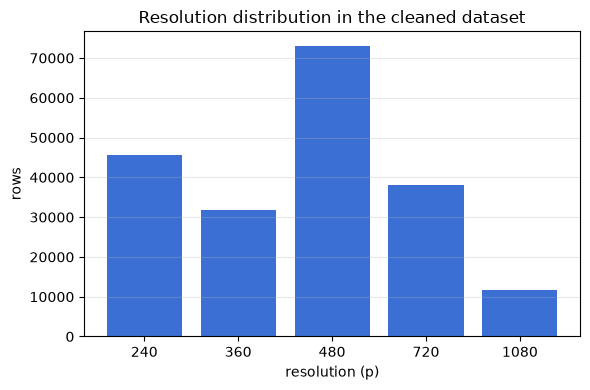

In [154]:
# Check for class imbalance across resolutions (flagged in cell 38 as a possible cause
# of the val-loss plateau)
res_counts = df.resolution.value_counts().reindex(LADDER)
res_props = res_counts / res_counts.sum()

print(res_counts)
print((res_props * 100).round(1).astype(str) + '%')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(res_counts.index.astype(str), res_counts.values, color='#3b6fd4')
ax.set_xlabel('resolution (p)')
ax.set_ylabel('rows')
ax.set_title('Resolution distribution in the cleaned dataset')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [155]:
# Reweight CrossEntropyLoss by inverse training-class frequency (train split only, so
# val/test balance never leaks into how the model is trained). The distribution above is
# heavily skewed, so every model from here on trains with this loss.
train_counts = pd.Series(y[tr]).value_counts().reindex(range(len(LADDER)), fill_value=0)
class_weights = torch.tensor(train_counts.sum() / (len(LADDER) * train_counts), dtype=torch.float32).to(device)
print(pd.DataFrame({'resolution': LADDER, 'train_count': train_counts.values, 'weight': class_weights.cpu().numpy()}))


   resolution  train_count    weight
0         240        27540  0.869354
1         360        19499  1.227858
2         480        43866  0.545799
3         720        22240  1.076529
4        1080         6565  3.646915


The resolution distribution above is heavily skewed toward 240p, so we'll weight the loss by inverse training-class frequency (`class_weights` above) for every model from here on. We should also sweep hidden state size, since 64 might already be higher than what the 2.4k training sequences can support well, along with dropout and weight decay.

### Hidden Size Sweep

Train a fresh model from the same initialization at each of 5 hidden state sizes, each using the same starting lr and `ReduceLROnPlateau` schedule as the main training run above. This isolates how much LSTM capacity matters, separate from the lr sweep below — useful here since the ~2.4k training sessions may not support a hidden size as large as 64 well.

In [157]:
# Sweep over 5 hidden state sizes, each run using the same starting lr and
# ReduceLROnPlateau schedule as the main training run so hidden size is the only thing that varies.

# The hidden state size of 8 is pretty much just for fun. I'm honestly curious if it can complete the task.
HIDDENS = [8, 16, 32, 64, 128]
HIDDEN_SWEEP_EPOCHS = 10

def train_with_hidden(hidden, epochs=HIDDEN_SWEEP_EPOCHS):
    torch.manual_seed(0)   # same init every run, so hidden size is the only thing that varies
    m = QoELSTM(n_features=features, n_classes=len(LADDER), hidden=hidden).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = []
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(m, train_loader, crit, opt, device)
        val_loss, val_acc = evaluate(m, val_loader, crit, device)
        sched.step(val_loss)
        hist.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                    'val_loss': val_loss, 'val_acc': val_acc, 'lr': opt.param_groups[0]['lr']})
    return hist

hidden_sweep_results = {hidden: train_with_hidden(hidden) for hidden in tqdm(HIDDENS, desc='hidden size sweep', unit='size')}

for hidden, hist in hidden_sweep_results.items():
    best = min(hist, key=lambda h: h['val_loss'])
    print(f'hidden={hidden}: best val_loss={best["val_loss"]:.4f}, val_acc={best["val_acc"]:.3f} (epoch {best["epoch"]})')


hidden size sweep: 100%|██████████| 5/5 [00:26<00:00,  5.22s/size]

hidden=8: best val_loss=0.6465, val_acc=0.764 (epoch 9)
hidden=16: best val_loss=0.5008, val_acc=0.794 (epoch 9)
hidden=32: best val_loss=0.4306, val_acc=0.832 (epoch 8)
hidden=64: best val_loss=0.3918, val_acc=0.842 (epoch 7)
hidden=128: best val_loss=0.3628, val_acc=0.850 (epoch 7)


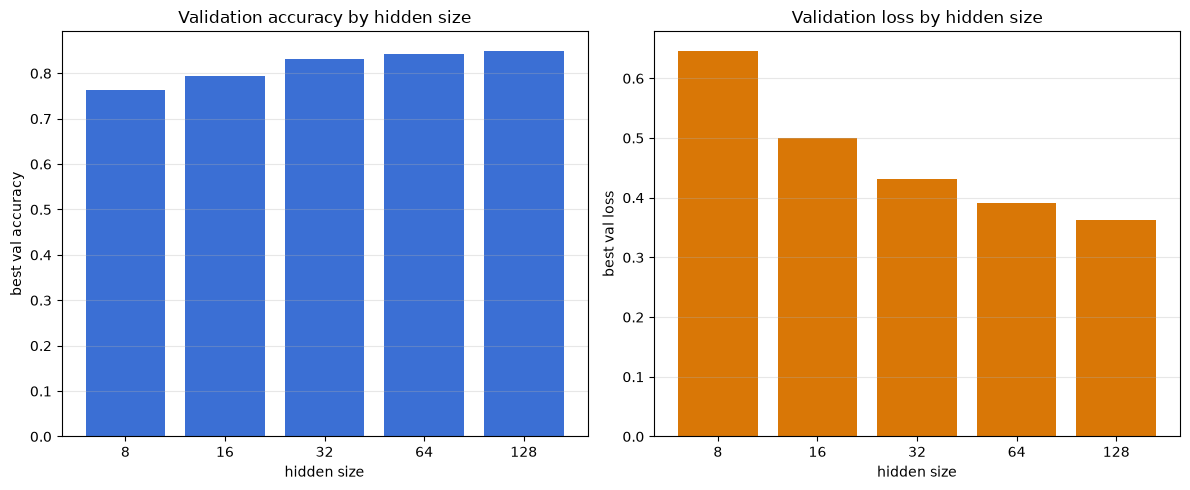

In [158]:
# Histogram comparing the best val accuracy / val loss reached at each hidden size
best_per_hidden = {hidden: min(hist, key=lambda h: h['val_loss']) for hidden, hist in hidden_sweep_results.items()}
hidden_labels = [str(h) for h in HIDDENS]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(hidden_labels, [best_per_hidden[h]['val_acc'] for h in HIDDENS], color='#3b6fd4')
ax[0].set_ylabel('best val accuracy')
ax[0].set_title('Validation accuracy by hidden size')

ax[1].bar(hidden_labels, [best_per_hidden[h]['val_loss'] for h in HIDDENS], color='#d97706')
ax[1].set_ylabel('best val loss')
ax[1].set_title('Validation loss by hidden size')

for a in ax:
    a.set_xlabel('hidden size')
    a.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


A hidden size of 128 seems to be the best. Let's fix 128 for now. I'm impressed by how well the size 8 model did, though.

### Epoch Sweep

Train fresh models (fixed `hidden=128`, `lr=1e-3`) for 15, 30, and 45 epochs to see whether the schedule is still improving val loss by epoch 15 or has already plateaued.

epoch sweep: 100%|██████████| 3/3 [00:44<00:00, 14.79s/run]


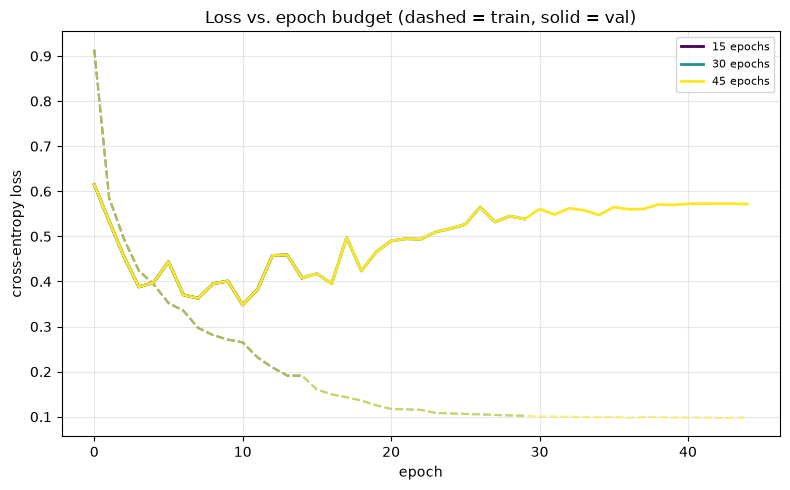

In [159]:
# Sweep over 3 epoch budgets, same fixed hidden=128 / lr=1e-3 as above -- loss curves only, no histogram
EPOCHS_LIST = [15, 30, 45]

def train_with_epochs(epochs):
    torch.manual_seed(0)   # same init every run, so epoch budget is the only thing that varies
    m = QoELSTM(n_features=features, n_classes=len(LADDER), hidden=128).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = []
    for epoch in range(epochs):
        train_loss, _ = train_one_epoch(m, train_loader, crit, opt, device)
        val_loss, _ = evaluate(m, val_loader, crit, device)
        sched.step(val_loss)
        hist.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    return hist

epoch_sweep_results = {epochs: train_with_epochs(epochs) for epochs in tqdm(EPOCHS_LIST, desc='epoch sweep', unit='run')}

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(EPOCHS_LIST)))
for color, epochs in zip(colors, EPOCHS_LIST):
    h = pd.DataFrame(epoch_sweep_results[epochs])
    ax.plot(h.epoch, h.train_loss, color=color, ls='--', alpha=0.6)
    ax.plot(h.epoch, h.val_loss, color=color, lw=2, label=f'{epochs} epochs')

ax.set_title('Loss vs. epoch budget (dashed = train, solid = val)')
ax.set_xlabel('epoch')
ax.set_ylabel('cross-entropy loss')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


The lines overlap. It definitely seems that when training for 30 or 45 epochs we just start overfitting as the validation loss rises but the train loss decreases. Even at 15 we seem to rise a bit... let's fix it at 10 for now, as this consistently seems to be the best model iteration. 

### Learning Rate Sweep

Train a fresh model from the same initialization at each of 5 starting learning rates, each using the same `ReduceLROnPlateau` schedule. This measures how much the starting lr matters once it's allowed to decay on a val-loss plateau, rather than comparing 5 fixed, never-adjusted lrs. We fix epochs = 10 and state size = 128 based on the above results.

In [160]:
# Sweep over 5 starting learning rates, each run using the same ReduceLROnPlateau
# schedule as the main training run so a run can still back off its lr on a plateau.
LRS = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
SWEEP_EPOCHS = 10

def train_with_lr(lr, epochs=SWEEP_EPOCHS):
    torch.manual_seed(0)   # same init every run, so lr is the only thing that varies
    m = QoELSTM(n_features=features, n_classes=len(LADDER), hidden=128).to(device)
    opt = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = []
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(m, train_loader, crit, opt, device)
        val_loss, val_acc = evaluate(m, val_loader, crit, device)
        sched.step(val_loss)
        hist.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                    'val_loss': val_loss, 'val_acc': val_acc, 'lr': opt.param_groups[0]['lr']})
    return hist

sweep_results = {lr: train_with_lr(lr) for lr in tqdm(LRS, desc='lr sweep', unit='lr')}

for lr, hist in sweep_results.items():
    best = min(hist, key=lambda h: h['val_loss'])
    print(f'lr={lr:.0e}: best val_loss={best["val_loss"]:.4f}, val_acc={best["val_acc"]:.3f} (epoch {best["epoch"]})')

lr sweep: 100%|██████████| 5/5 [00:25<00:00,  5.04s/lr]

lr=1e-04: best val_loss=0.5277, val_acc=0.797 (epoch 9)
lr=3e-04: best val_loss=0.4212, val_acc=0.828 (epoch 8)
lr=1e-03: best val_loss=0.3628, val_acc=0.850 (epoch 7)
lr=3e-03: best val_loss=0.3582, val_acc=0.867 (epoch 9)
lr=1e-02: best val_loss=0.3324, val_acc=0.865 (epoch 9)


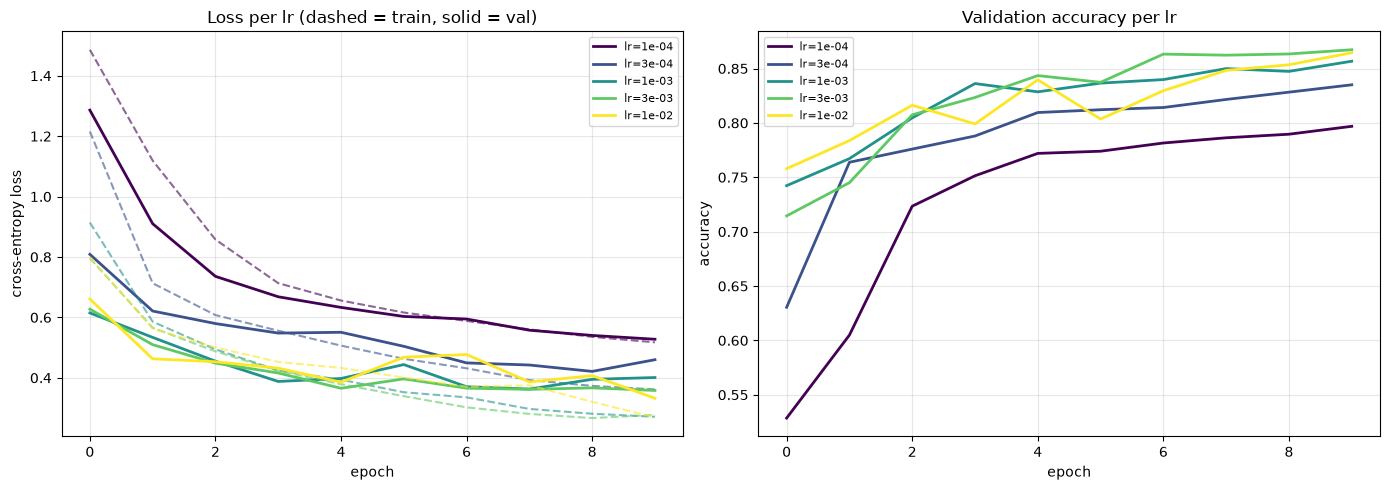

In [163]:
# Loss curves per lr: dashed = train, solid = val. Also show val accuracy per lr for reference.
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(LRS)))

for color, lr in zip(colors, LRS):
    h = pd.DataFrame(sweep_results[lr])
    ax[0].plot(h.epoch, h.train_loss, color=color, ls='--', alpha=0.6)
    ax[0].plot(h.epoch, h.val_loss, color=color, lw=2, label=f'lr={lr:.0e}')
    ax[1].plot(h.epoch, h.val_acc, color=color, lw=2, label=f'lr={lr:.0e}')

ax[0].set_title('Loss per lr (dashed = train, solid = val)')
ax[0].set_ylabel('cross-entropy loss')
ax[1].set_title('Validation accuracy per lr')
ax[1].set_ylabel('accuracy')

for a in ax:
    a.set_xlabel('epoch')
    a.grid(alpha=0.3)
    a.legend(fontsize=8)

plt.tight_layout()
plt.show()

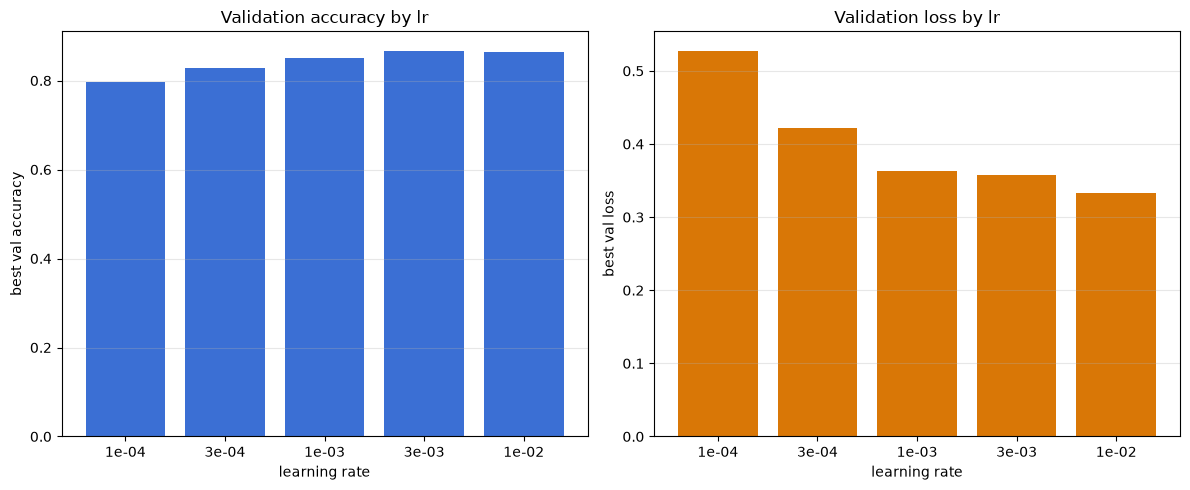

In [162]:
# Histogram comparing the best val accuracy / val loss reached at each lr
best_per_lr = {lr: min(hist, key=lambda h: h['val_loss']) for lr, hist in sweep_results.items()}
lr_labels = [f'{lr:.0e}' for lr in LRS]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(lr_labels, [best_per_lr[lr]['val_acc'] for lr in LRS], color='#3b6fd4')
ax[0].set_ylabel('best val accuracy')
ax[0].set_title('Validation accuracy by lr')

ax[1].bar(lr_labels, [best_per_lr[lr]['val_loss'] for lr in LRS], color='#d97706')
ax[1].set_ylabel('best val loss')
ax[1].set_title('Validation loss by lr')

for a in ax:
    a.set_xlabel('learning rate')
    a.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

3e-03 looks best. Fix lr = 3e-03 from now on.

### Dropout Sweep

Train a fresh model from the same initialization at each of 5 dropout rates, with `lr=3e-3`, `hidden=128`, and `epochs=10` fixed at the values selected above.

In [164]:
# Sweep over 5 dropout rates, same fixed lr=3e-3 / hidden=128 / epochs=10 as above.
DROPOUTS = [0.1, 0.2, 0.3, 0.4, 0.5]
DROPOUT_EPOCHS = 10

def train_with_dropout(dropout, epochs=DROPOUT_EPOCHS):
    torch.manual_seed(0)   # same init every run, so dropout is the only thing that varies
    m = QoELSTM(n_features=features, n_classes=len(LADDER), hidden=128, dropout=dropout).to(device)
    opt = optim.Adam(m.parameters(), lr=3e-3, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = []
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(m, train_loader, crit, opt, device)
        val_loss, val_acc = evaluate(m, val_loader, crit, device)
        sched.step(val_loss)
        hist.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                    'val_loss': val_loss, 'val_acc': val_acc})
    return hist

dropout_sweep_results = {d: train_with_dropout(d) for d in tqdm(DROPOUTS, desc='dropout sweep', unit='rate')}

for d, hist in dropout_sweep_results.items():
    best = min(hist, key=lambda h: h['val_loss'])
    print(f'dropout={d:.1f}: best val_loss={best["val_loss"]:.4f}, val_acc={best["val_acc"]:.3f} (epoch {best["epoch"]})')


dropout sweep: 100%|██████████| 5/5 [00:24<00:00,  4.90s/rate]

dropout=0.1: best val_loss=0.3632, val_acc=0.868 (epoch 9)
dropout=0.2: best val_loss=0.3679, val_acc=0.845 (epoch 6)
dropout=0.3: best val_loss=0.3582, val_acc=0.867 (epoch 9)
dropout=0.4: best val_loss=0.3544, val_acc=0.863 (epoch 9)
dropout=0.5: best val_loss=0.3619, val_acc=0.864 (epoch 9)


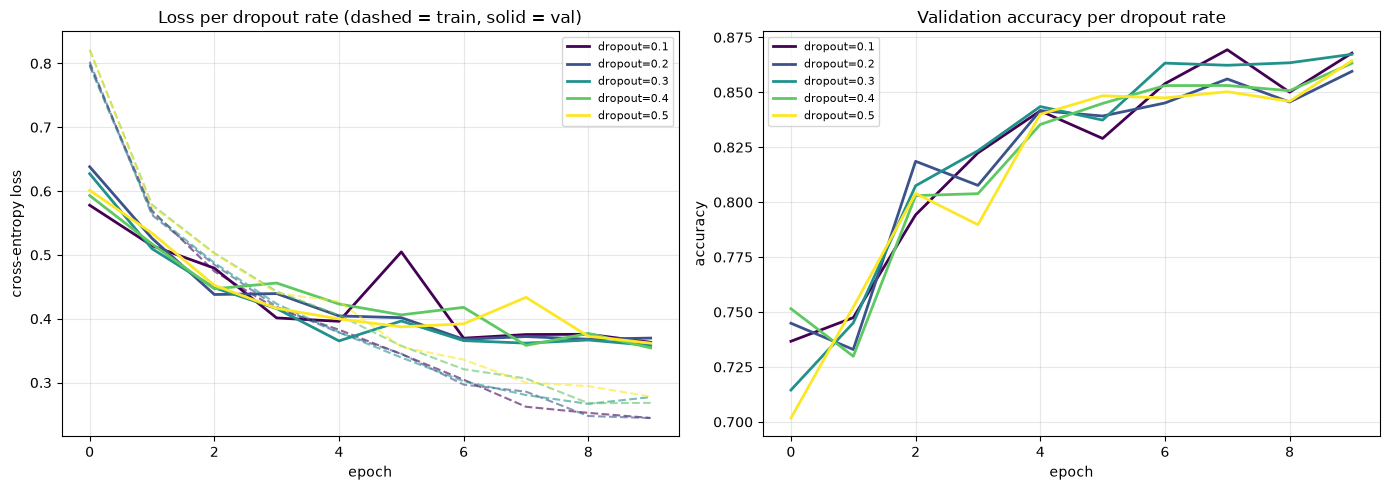

In [165]:
# Loss curves per dropout rate: dashed = train, solid = val. Also show val accuracy for reference.
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(DROPOUTS)))

for color, d in zip(colors, DROPOUTS):
    h = pd.DataFrame(dropout_sweep_results[d])
    ax[0].plot(h.epoch, h.train_loss, color=color, ls='--', alpha=0.6)
    ax[0].plot(h.epoch, h.val_loss, color=color, lw=2, label=f'dropout={d:.1f}')
    ax[1].plot(h.epoch, h.val_acc, color=color, lw=2, label=f'dropout={d:.1f}')

ax[0].set_title('Loss per dropout rate (dashed = train, solid = val)')
ax[0].set_ylabel('cross-entropy loss')
ax[1].set_title('Validation accuracy per dropout rate')
ax[1].set_ylabel('accuracy')

for a in ax:
    a.set_xlabel('epoch')
    a.grid(alpha=0.3)
    a.legend(fontsize=8)

plt.tight_layout()
plt.show()


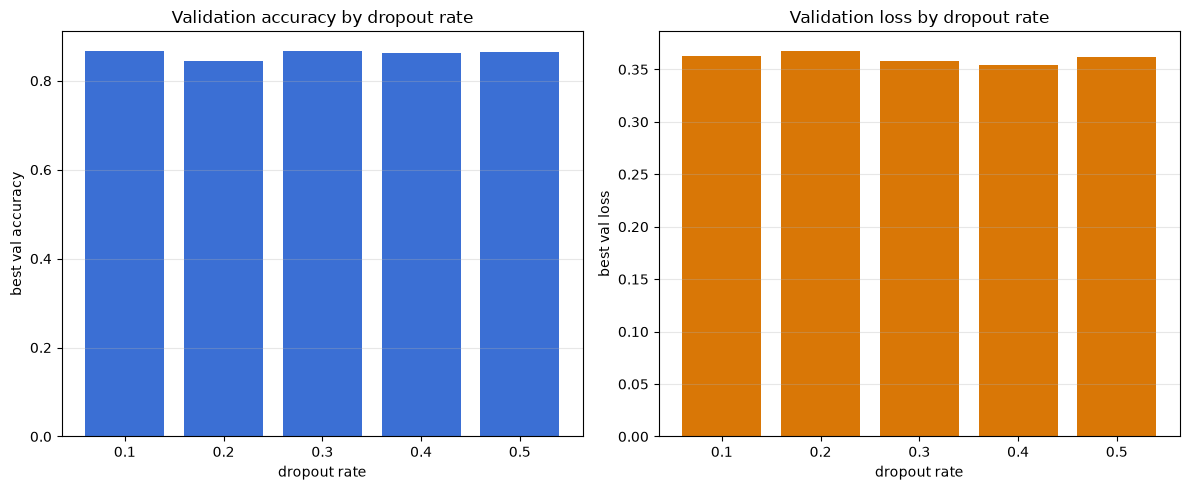

In [166]:
# Histogram comparing the best val accuracy / val loss reached at each dropout rate
best_per_dropout = {d: min(hist, key=lambda h: h['val_loss']) for d, hist in dropout_sweep_results.items()}
dropout_labels = [f'{d:.1f}' for d in DROPOUTS]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(dropout_labels, [best_per_dropout[d]['val_acc'] for d in DROPOUTS], color='#3b6fd4')
ax[0].set_ylabel('best val accuracy')
ax[0].set_title('Validation accuracy by dropout rate')

ax[1].bar(dropout_labels, [best_per_dropout[d]['val_loss'] for d in DROPOUTS], color='#d97706')
ax[1].set_ylabel('best val loss')
ax[1].set_title('Validation loss by dropout rate')

for a in ax:
    a.set_xlabel('dropout rate')
    a.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


Dropout = 0.3 looks best. Fix dropout = 0.3.

### Weight Decay Sweep

Train a fresh model from the same initialization at each of 5 weight decay values, with `lr=3e-3`, `hidden=128`, `dropout=0.3`, and `epochs=10` fixed at the values selected above.

In [167]:
# Sweep over 5 weight decay values, same fixed lr=3e-3 / hidden=128 / dropout=0.3 / epochs=15 as above.
WEIGHT_DECAYS = [0, 1e-5, 1e-4, 1e-3, 1e-2]
WD_EPOCHS = 10

def train_with_weight_decay(weight_decay, epochs=WD_EPOCHS):
    torch.manual_seed(0)   # same init every run, so weight decay is the only thing that varies
    m = QoELSTM(n_features=features, n_classes=len(LADDER), hidden=128, dropout=0.3).to(device)
    opt = optim.Adam(m.parameters(), lr=3e-3, weight_decay=weight_decay)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = []
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(m, train_loader, crit, opt, device)
        val_loss, val_acc = evaluate(m, val_loader, crit, device)
        sched.step(val_loss)
        hist.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                    'val_loss': val_loss, 'val_acc': val_acc})
    return hist

wd_sweep_results = {wd: train_with_weight_decay(wd) for wd in tqdm(WEIGHT_DECAYS, desc='weight decay sweep', unit='run')}

for wd, hist in wd_sweep_results.items():
    best = min(hist, key=lambda h: h['val_loss'])
    print(f'weight_decay={wd:.0e}: best val_loss={best["val_loss"]:.4f}, val_acc={best["val_acc"]:.3f} (epoch {best["epoch"]})')


weight decay sweep: 100%|██████████| 5/5 [00:24<00:00,  4.95s/run]

weight_decay=0e+00: best val_loss=0.3572, val_acc=0.853 (epoch 7)
weight_decay=1e-05: best val_loss=0.3582, val_acc=0.867 (epoch 9)
weight_decay=1e-04: best val_loss=0.3173, val_acc=0.874 (epoch 9)
weight_decay=1e-03: best val_loss=0.3927, val_acc=0.838 (epoch 6)
weight_decay=1e-02: best val_loss=0.5116, val_acc=0.812 (epoch 9)


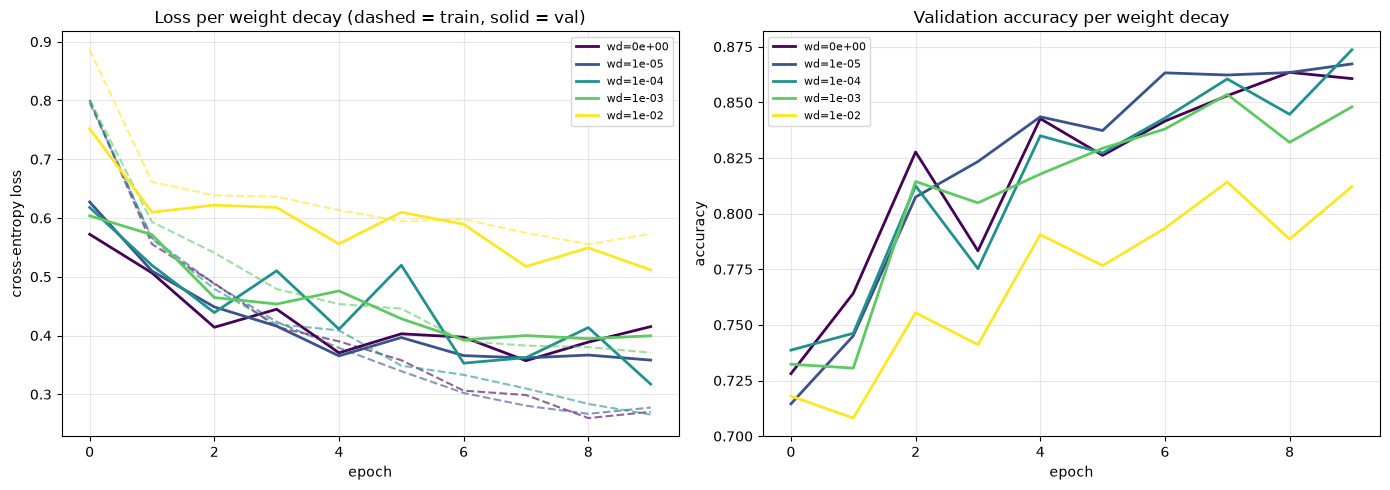

In [168]:
# Loss curves per weight decay: dashed = train, solid = val. Also show val accuracy for reference.
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(WEIGHT_DECAYS)))

for color, wd in zip(colors, WEIGHT_DECAYS):
    h = pd.DataFrame(wd_sweep_results[wd])
    ax[0].plot(h.epoch, h.train_loss, color=color, ls='--', alpha=0.6)
    ax[0].plot(h.epoch, h.val_loss, color=color, lw=2, label=f'wd={wd:.0e}')
    ax[1].plot(h.epoch, h.val_acc, color=color, lw=2, label=f'wd={wd:.0e}')

ax[0].set_title('Loss per weight decay (dashed = train, solid = val)')
ax[0].set_ylabel('cross-entropy loss')
ax[1].set_title('Validation accuracy per weight decay')
ax[1].set_ylabel('accuracy')

for a in ax:
    a.set_xlabel('epoch')
    a.grid(alpha=0.3)
    a.legend(fontsize=8)

plt.tight_layout()
plt.show()


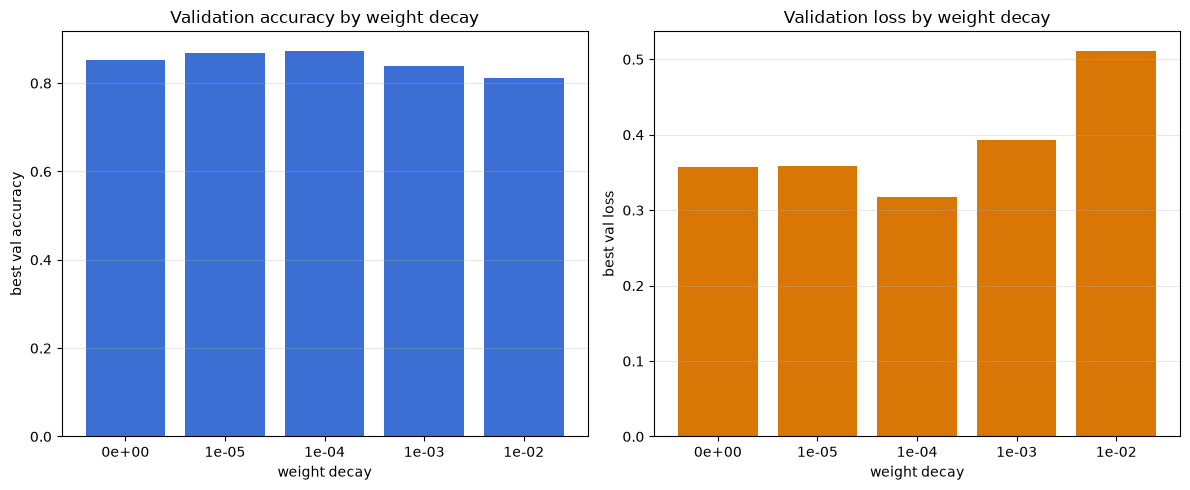

In [169]:
# Histogram comparing the best val accuracy / val loss reached at each weight decay value
best_per_wd = {wd: min(hist, key=lambda h: h['val_loss']) for wd, hist in wd_sweep_results.items()}
wd_labels = [f'{wd:.0e}' for wd in WEIGHT_DECAYS]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(wd_labels, [best_per_wd[wd]['val_acc'] for wd in WEIGHT_DECAYS], color='#3b6fd4')
ax[0].set_ylabel('best val accuracy')
ax[0].set_title('Validation accuracy by weight decay')

ax[1].bar(wd_labels, [best_per_wd[wd]['val_loss'] for wd in WEIGHT_DECAYS], color='#d97706')
ax[1].set_ylabel('best val loss')
ax[1].set_title('Validation loss by weight decay')

for a in ax:
    a.set_xlabel('weight decay')
    a.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


Fix weight decay = 1e-04. Our final hyperparameters are:
lr: ```3e-03```
hidden state size: ```128```
epochs: ```10```
dropout: ```0.3```
weight decay: ```1e-04```

Let's train + save our final model in ```checkpoints/m2```

In [170]:
features = Xtr.shape[2]
model = QoELSTM(n_features=features, hidden=128, dropout=0.3)
model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)   # ignore_index=-100 is the default
optimizer = optim.Adam(model.parameters(), lr=3e-03, weight_decay=1e-04)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                factor=0.5, patience=3)

history, best_val_loss = train_model()


training:   0%|          | 0/10 [00:00<?, ?epoch/s]

training: 100%|██████████| 10/10 [00:05<00:00,  1.89epoch/s, best=*, train=0.2775, val=0.3553, val_acc=0.857]

best val loss: 0.3553


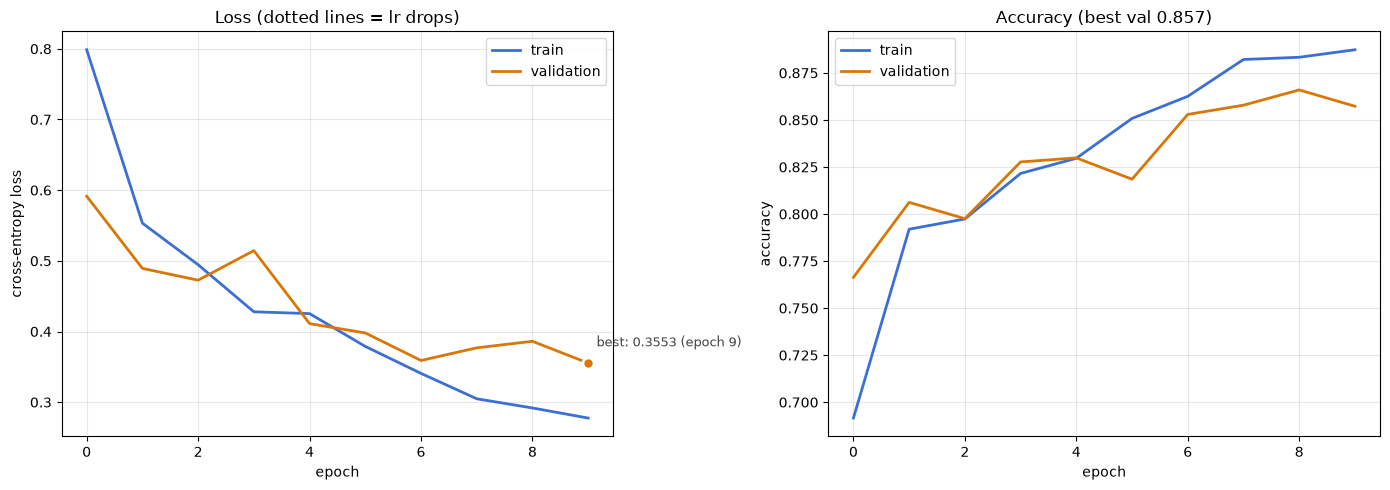

In [171]:
# Loss curves for the final model
plot_stats(history)


In [172]:
CKPT_DIR = Path('checkpoints/m2')
save_model(CKPT_DIR)

saved checkpoints/m2/qoe_lstm.pt (1.1 MB), best val loss 0.3553


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

In [173]:
# Reload the final model instead of retraining, now that checkpoints/m2 exists
CKPT_DIR = Path('checkpoints/m2')
model = load_model(ckpt_dir=CKPT_DIR)

model.eval()

loaded model trained to val loss 0.3553 over 10 epochs


QoELSTM(
  (lstm): LSTM(159, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=128, out_features=5, bias=True)
)

In [174]:
@torch.no_grad()
def evaluate_test_set(model, loader, device):
    """Run the model over a loader and return masked, per-timestep true labels,
    predicted labels, and class probabilities (for accuracy / F1 / confusion matrix / ROC-AUC)."""
    model.eval()
    all_true, all_pred, all_probs = [], [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)                       # (batch, seq, n_classes)
        probs = torch.softmax(logits, dim=-1)

        flat_y = y.reshape(-1)
        flat_probs = probs.reshape(-1, probs.size(-1))
        mask = flat_y != -100                   # drop padded timesteps, same as training/val scoring

        all_true.append(flat_y[mask].cpu().numpy())
        all_pred.append(flat_probs[mask].argmax(-1).cpu().numpy())
        all_probs.append(flat_probs[mask].cpu().numpy())

    return np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_probs)

y_true, y_pred, y_probs = evaluate_test_set(model, test_loader, device)
print(f'{len(y_true)} test timesteps evaluated')


40268 test timesteps evaluated


resolution
240     45538
360     31713
480     73056
720     37986
1080    11770
Name: count, dtype: int64
resolution
240     22.8%
360     15.9%
480     36.5%
720     19.0%
1080     5.9%
Name: count, dtype: object


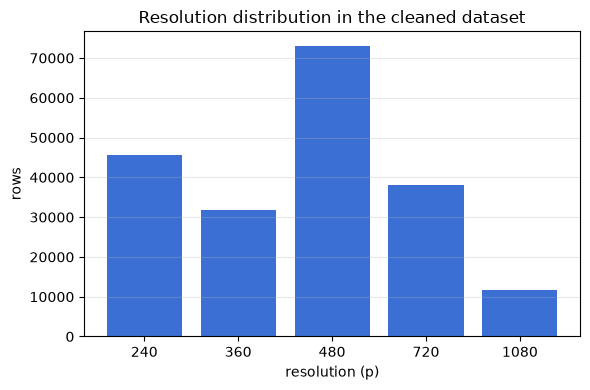

In [175]:
# Plot the resolution distribution again to contextualize our metrics

res_counts = df.resolution.value_counts().reindex(LADDER)
res_props = res_counts / res_counts.sum()

print(res_counts)
print((res_props * 100).round(1).astype(str) + '%')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(res_counts.index.astype(str), res_counts.values, color='#3b6fd4')
ax.set_xlabel('resolution (p)')
ax.set_ylabel('rows')
ax.set_title('Resolution distribution in the cleaned dataset')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

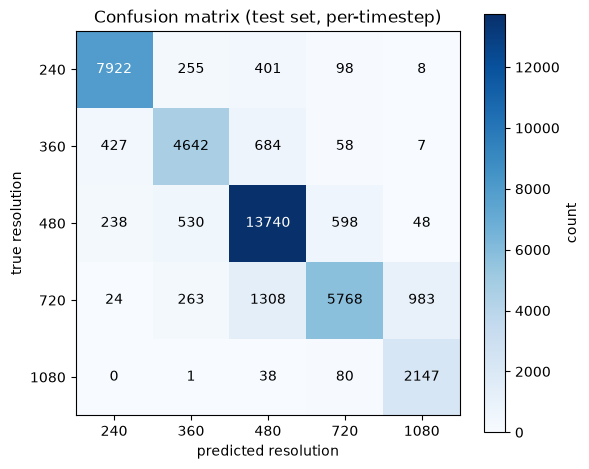

In [176]:
# 5x5 confusion matrix over all test timesteps, labeled by resolution rather than class index
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=range(len(LADDER)))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(LADDER)))
ax.set_yticks(range(len(LADDER)))
ax.set_xticklabels(LADDER)
ax.set_yticklabels(LADDER)
ax.set_xlabel('predicted resolution')
ax.set_ylabel('true resolution')
ax.set_title('Confusion matrix (test set, per-timestep)')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, cm[i, j], ha='center', va='center', color=color)

fig.colorbar(im, ax=ax, label='count')
plt.tight_layout()
plt.show()


In [177]:
def per_class_accuracy(y_true, y_pred, n_classes):
    """Accuracy restricted to timesteps whose true label is each class (per-class recall)."""
    accs = []
    for c in range(n_classes):
        mask = y_true == c
        accs.append((y_pred[mask] == y_true[mask]).mean() if mask.sum() > 0 else np.nan)
    return np.array(accs)

class_acc = per_class_accuracy(y_true, y_pred, len(LADDER))
overall_acc = (y_pred == y_true).mean()

for res, acc in zip(LADDER, class_acc):
    print(f'{res}p: accuracy={acc:.3f}')
print(f'overall accuracy: {overall_acc:.3f}')


240p: accuracy=0.912
360p: accuracy=0.798
480p: accuracy=0.907
720p: accuracy=0.691
1080p: accuracy=0.947
overall accuracy: 0.850


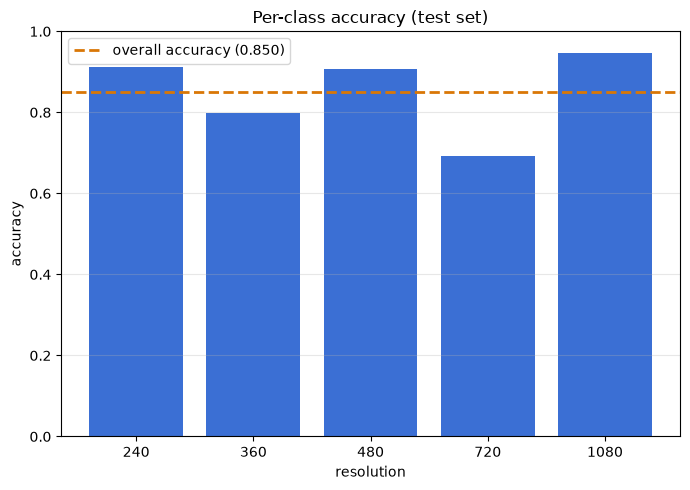

In [178]:
# Histogram of per-class accuracy, overall accuracy shown as a reference line
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar([str(r) for r in LADDER], class_acc, color='#3b6fd4')
ax.axhline(overall_acc, color='#d97706', ls='--', lw=2, label=f'overall accuracy ({overall_acc:.3f})')

ax.set_xlabel('resolution')
ax.set_ylabel('accuracy')
ax.set_title('Per-class accuracy (test set)')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()


In [179]:
from sklearn.metrics import precision_score, recall_score

class_precision = precision_score(y_true, y_pred, labels=range(len(LADDER)), average=None, zero_division=0)
class_recall = recall_score(y_true, y_pred, labels=range(len(LADDER)), average=None, zero_division=0)
macro_precision = precision_score(y_true, y_pred, labels=range(len(LADDER)), average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, labels=range(len(LADDER)), average='macro', zero_division=0)

for res, p, r in zip(LADDER, class_precision, class_recall):
    print(f'{res}p: precision={p:.3f}, recall={r:.3f}')
print(f'macro precision: {macro_precision:.3f}')
print(f'macro recall: {macro_recall:.3f}')


240p: precision=0.920, recall=0.912
360p: precision=0.816, recall=0.798
480p: precision=0.850, recall=0.907
720p: precision=0.874, recall=0.691
1080p: precision=0.672, recall=0.947
macro precision: 0.826
macro recall: 0.851


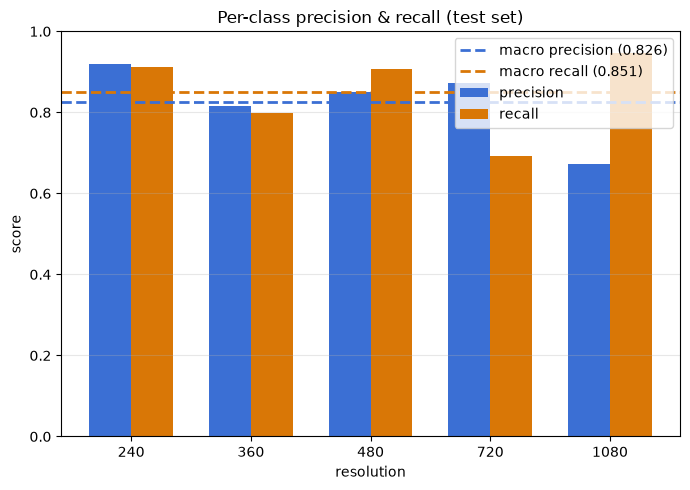

In [180]:
# Grouped histogram: per-class precision & recall, macro values shown as reference lines
x = np.arange(len(LADDER))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, class_precision, width, color='#3b6fd4', label='precision')
ax.bar(x + width/2, class_recall, width, color='#d97706', label='recall')

ax.axhline(macro_precision, color='#3b6fd4', ls='--', lw=2, label=f'macro precision ({macro_precision:.3f})')
ax.axhline(macro_recall, color='#d97706', ls='--', lw=2, label=f'macro recall ({macro_recall:.3f})')

ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in LADDER])
ax.set_xlabel('resolution')
ax.set_ylabel('score')
ax.set_title('Per-class precision & recall (test set)')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()


In [181]:
from sklearn.metrics import f1_score

def per_class_f1(y_true, y_pred, n_classes):
    return f1_score(y_true, y_pred, labels=range(n_classes), average=None, zero_division=0)

class_f1 = per_class_f1(y_true, y_pred, len(LADDER))
macro_f1 = f1_score(y_true, y_pred, labels=range(len(LADDER)), average='macro', zero_division=0)

for res, f1 in zip(LADDER, class_f1):
    print(f'{res}p: f1={f1:.3f}')
print(f'macro f1: {macro_f1:.3f}')

# Random-chance baseline: predictions drawn uniformly at random over the 5 classes,
# scored the exact same way as the real model
rng = np.random.default_rng(0)
y_pred_chance = rng.integers(0, len(LADDER), size=len(y_true))

class_f1_chance = per_class_f1(y_true, y_pred_chance, len(LADDER))
macro_f1_chance = f1_score(y_true, y_pred_chance, labels=range(len(LADDER)), average='macro', zero_division=0)

for res, f1 in zip(LADDER, class_f1_chance):
    print(f'{res}p: random-chance f1={f1:.3f}')
print(f'random-chance macro f1: {macro_f1_chance:.3f}')


240p: f1=0.916
360p: f1=0.807
480p: f1=0.877
720p: f1=0.772
1080p: f1=0.787
macro f1: 0.832
240p: random-chance f1=0.210
360p: random-chance f1=0.169
480p: random-chance f1=0.263
720p: random-chance f1=0.207
1080p: random-chance f1=0.090
random-chance macro f1: 0.187


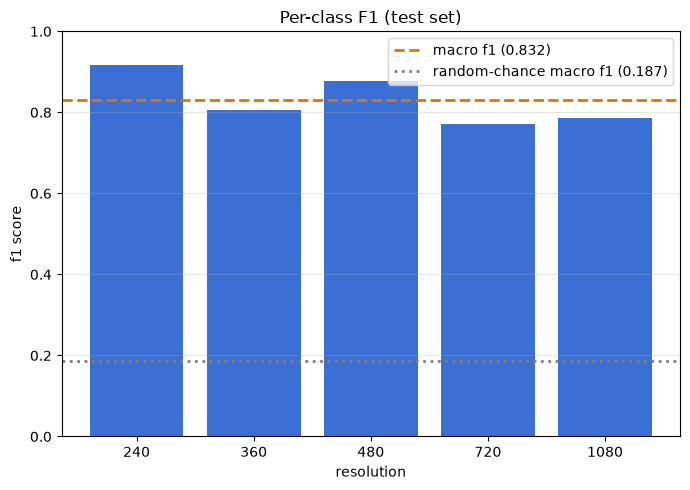

In [182]:
# Histogram of per-class F1, macro F1 shown as a reference line
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar([str(r) for r in LADDER], class_f1, color='#3b6fd4')
ax.axhline(macro_f1, color='#d97706', ls='--', lw=2, label=f'macro f1 ({macro_f1:.3f})')
ax.axhline(macro_f1_chance, color='gray', ls=':', lw=2, label=f'random-chance macro f1 ({macro_f1_chance:.3f})')

ax.set_xlabel('resolution')
ax.set_ylabel('f1 score')
ax.set_title('Per-class F1 (test set)')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()


Let's look at ROC / AUC

240p: AUC=0.991
360p: AUC=0.962
480p: AUC=0.970
720p: AUC=0.966
1080p: AUC=0.991


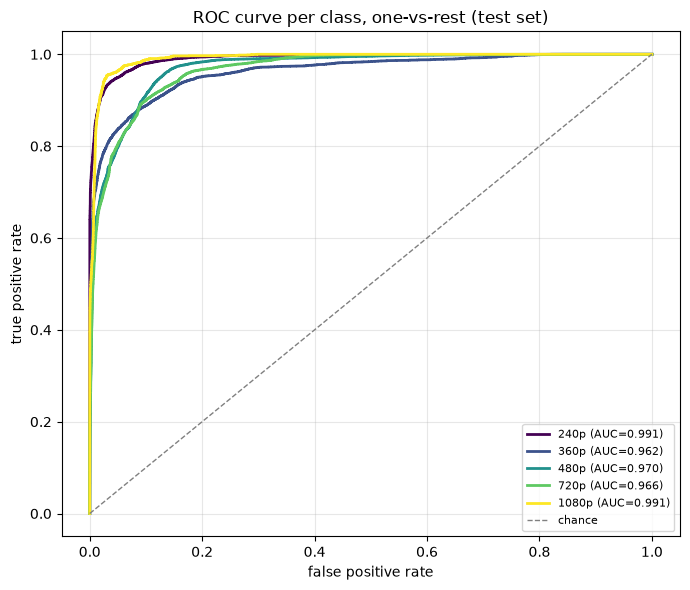

In [183]:
# Per-class ROC / AUC (one-vs-rest): binarize the true labels, one binary problem per class
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=range(len(LADDER)))   # (N, n_classes)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(LADDER)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

for res, i in zip(LADDER, range(len(LADDER))):
    print(f'{res}p: AUC={roc_auc[i]:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(LADDER)))
for i, color in zip(range(len(LADDER)), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{LADDER[i]}p (AUC={roc_auc[i]:.3f})')
ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=1, label='chance')

ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC curve per class, one-vs-rest (test set)')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


macro-average AUC: 0.976


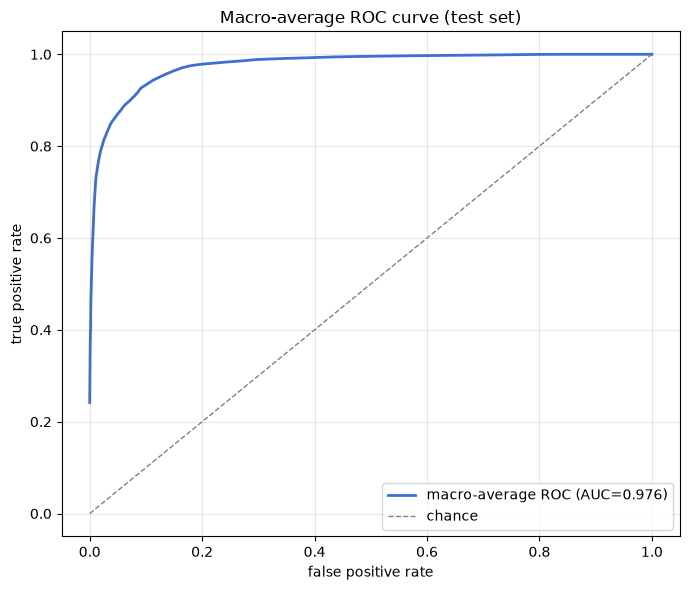

In [184]:
# Macro-average ROC: interpolate every per-class curve onto a shared FPR grid, then average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(LADDER))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(LADDER)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(LADDER)

macro_fpr, macro_tpr = all_fpr, mean_tpr
macro_auc = auc(macro_fpr, macro_tpr)
print(f'macro-average AUC: {macro_auc:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(macro_fpr, macro_tpr, color='#3b6fd4', lw=2, label=f'macro-average ROC (AUC={macro_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=1, label='chance')

ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('Macro-average ROC curve (test set)')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


The AUC is quite good (macro-average AUC is 0.976), but precision and recall weren't nearly as good. This result just points back to class imbalance in the dataset. 1080p gets an AUC of 0.991, but it is also a very rare class, and the negative pool is > 90% of the data. The false positives are enough to hurt precision, but not FPR, so the curve still is close to the left corner. 

## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

In [187]:
# Grab a session from the test partition -- pick the one with the most resolution changes,
# so the plot actually shows the model tracking bitrate switches, not just a flat line.
test_session_ids = np.unique(groups[te])

def num_changes(y_seq):
    return int((y_seq[1:] != y_seq[:-1]).sum())

n_changes = [num_changes(yte[i, :len_te[i]].numpy()) for i in range(len(test_session_ids))]
sess_idx = int(np.argmax(n_changes))
sess_id = test_session_ids[sess_idx]
L = len_te[sess_idx].item()

print(f'session {sess_id}: {L} timesteps, {n_changes[sess_idx]} resolution changes')

# Run inference on just this session (trim off the padding first)
model.eval()
with torch.no_grad():
    X_sess = Xte[sess_idx:sess_idx+1, :L].to(device)         # (1, L, n_features)
    logits = model(X_sess)                                    # (1, L, n_classes)
    pred_idx = logits.argmax(-1).squeeze(0).cpu().numpy()     # (L,)

true_idx = yte[sess_idx, :L].numpy()
true_res = np.array(LADDER)[true_idx]
pred_res = np.array(LADDER)[pred_idx]
time_s = (np.arange(L) + 1) * 10   # 10s cadence, confirmed earlier: every row is one 10s tick

acc = (pred_idx == true_idx).mean()
print(f'per-timestep accuracy on this session: {acc:.3f}')


session a829860a31fa4d8c86064397e8064efb: 48 timesteps, 22 resolution changes
per-timestep accuracy on this session: 0.312


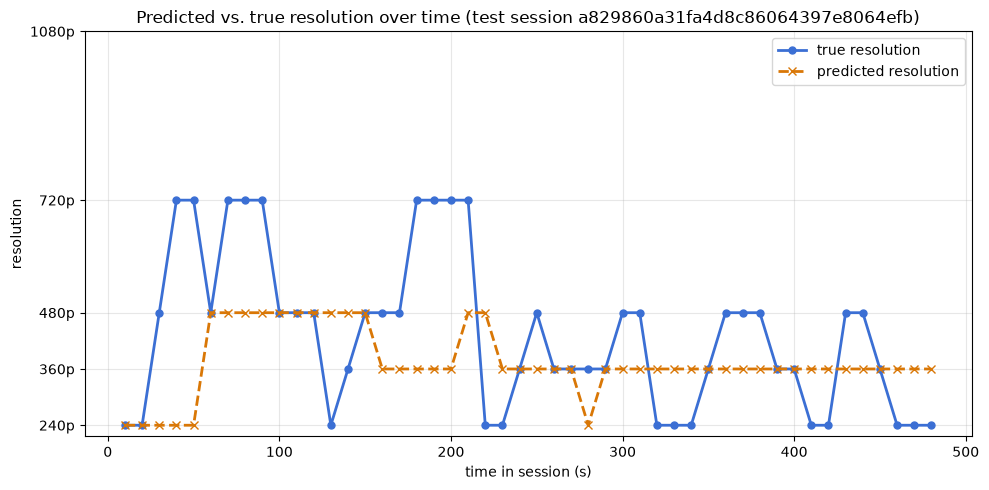

In [188]:
# Real vs. predicted resolution over the session, at 10s intervals
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_s, true_res, color='#3b6fd4', lw=2, marker='o', ms=5, label='true resolution')
ax.plot(time_s, pred_res, color='#d97706', lw=2, ls='--', marker='x', ms=6, label='predicted resolution')

ax.set_yticks(LADDER)
ax.set_yticklabels([f'{r}p' for r in LADDER])
ax.set_xlabel('time in session (s)')
ax.set_ylabel('resolution')
ax.set_title(f'Predicted vs. true resolution over time (test session {sess_id})')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


For the timeseries with the most changes (arguably the hardest one) the model does not perform very well. I'm not surprised, though, since some of these resolution changes are extremely quick and only last for one ten second interval.

In [189]:
# Also grab the test session closest to the median number of resolution changes,
# to see how the model does on a "typical" session rather than the hardest one
median_changes = np.median(n_changes)
sess_idx_med = int(np.argmin(np.abs(np.array(n_changes) - median_changes)))
sess_id_med = test_session_ids[sess_idx_med]
L_med = len_te[sess_idx_med].item()

print(f'median changes across test sessions: {median_changes:.1f}')
print(f'session {sess_id_med}: {L_med} timesteps, {n_changes[sess_idx_med]} resolution changes')

model.eval()
with torch.no_grad():
    X_sess_med = Xte[sess_idx_med:sess_idx_med+1, :L_med].to(device)
    logits_med = model(X_sess_med)
    pred_idx_med = logits_med.argmax(-1).squeeze(0).cpu().numpy()

true_idx_med = yte[sess_idx_med, :L_med].numpy()
true_res_med = np.array(LADDER)[true_idx_med]
pred_res_med = np.array(LADDER)[pred_idx_med]
time_s_med = (np.arange(L_med) + 1) * 10

acc_med = (pred_idx_med == true_idx_med).mean()
print(f'per-timestep accuracy on this session: {acc_med:.3f}')


median changes across test sessions: 1.0
session 00d9a4682af553cb0ba989169b1c0c23: 48 timesteps, 1 resolution changes
per-timestep accuracy on this session: 0.958


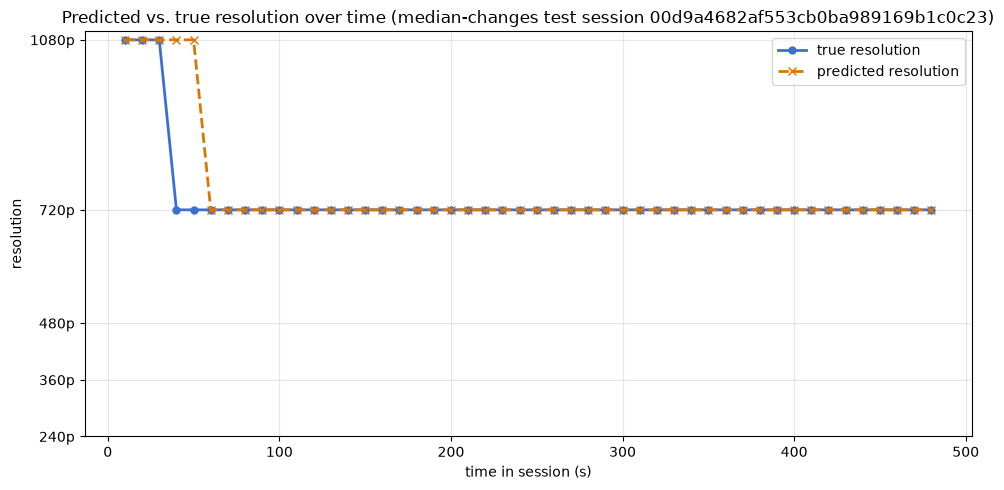

In [190]:
# Real vs. predicted resolution for the median-changes session, at 10s intervals
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_s_med, true_res_med, color='#3b6fd4', lw=2, marker='o', ms=5, label='true resolution')
ax.plot(time_s_med, pred_res_med, color='#d97706', lw=2, ls='--', marker='x', ms=6, label='predicted resolution')

ax.set_yticks(LADDER)
ax.set_yticklabels([f'{r}p' for r in LADDER])
ax.set_xlabel('time in session (s)')
ax.set_ylabel('resolution')
ax.set_title(f'Predicted vs. true resolution over time (median-changes test session {sess_id_med})')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


Choosing a median timeseries shows much better performance. It also appears that the model lags behind in its predictions somewhat.